# 03 — เทียบกับกระบวนการที่ควรเป็น (Conformance Checking)

คำถามที่ตอบ: กี่เปอร์เซ็นต์ของเคสเดินตามลำดับที่ควรเป็น ที่เบี่ยงไปเบี่ยงแบบไหน และมีการข้ามขั้นตอนสำคัญหรือลำดับผิดหรือไม่ เช่น จ่ายเงินก่อนรับของ

ตรวจ 2 ชั้น
1. **ระดับเคส (โมเดลอ้างอิง):** ใช้ token-based replay และ alignments ตรวจลำดับขั้นใหญ่ของทั้งเคส
2. **ระดับเอกสาร (กฎธุรกิจ):** ตรวจทีละเอกสาร เพราะเคสหนึ่งมีหลาย PO/GR การตรวจลำดับระดับเคสอย่างเดียวจะปนการสลับลำดับระหว่างเอกสารคนละใบ

ข้อมูลเป็น **ข้อมูลจำลอง** สาเหตุทุกข้อเป็นข้อสันนิษฐาน

In [1]:
import os; os.environ['PM4PY_SHOW_PROGRESS_BAR'] = 'False'
import sys, json
from pathlib import Path
from collections import Counter
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd, matplotlib.pyplot as plt, pm4py
from pm4py.objects.process_tree.utils.generic import parse
import p2p_data as d
FIG = Path.cwd().parent/'figures'; R = {}
df = d.load_case_log()
log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')
con = d.connect(); xo = d.event_object_table(con)
case_of_event = df.set_index('ocel_event_id')['case:concept:name']
xo['case'] = xo.ocel_event_id.map(case_of_event)
N = df['case:concept:name'].nunique(); R['cases'] = N

## 1. โมเดลอ้างอิง (reference model)
นิยามจากหลัก P2P ทั่วไป โดยใช้ชื่อ activity จริงในไฟล์:

1. สร้างใบขอซื้อ → อนุมัติใบขอซื้อ → ขอใบเสนอราคา
2. สร้างและอนุมัติ PO (หลายใบได้)
3. รับของ, รับใบแจ้งหนี้, จับคู่ (หลายรอบได้ ไม่บังคับลำดับในชั้นนี้ เพราะเคสมีหลายเอกสาร ลำดับระหว่างเอกสารตรวจในข้อ 3)
4. **จ่ายเงินครั้งเดียว เป็นขั้นสุดท้าย**

ข้อสังเกต: ในโมเดลนี้ `Delegate Purchase Requisition Approval` ไม่ใช่ขั้นปกติ เพราะการส่งต่อให้คนอื่นอนุมัติควรตามด้วยการอนุมัติจริงที่บันทึกในระบบ

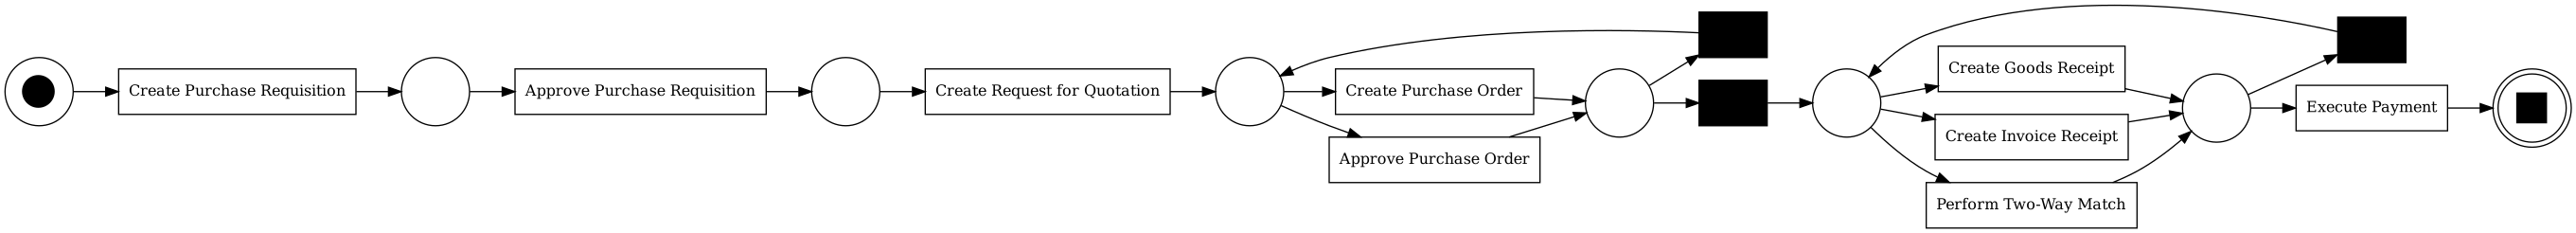

In [2]:
REF = ("->( 'Create Purchase Requisition', 'Approve Purchase Requisition', 'Create Request for Quotation', "
       "*( X( 'Create Purchase Order', 'Approve Purchase Order' ), tau ), "
       "*( X( 'Create Goods Receipt', 'Create Invoice Receipt', 'Perform Two-Way Match' ), tau ), "
       "'Execute Payment' )")
tree = parse(REF); R['reference_tree'] = REF
net, im, fm = pm4py.convert_to_petri_net(tree)
pm4py.save_vis_process_tree(tree, str(FIG/'03_reference_tree.png'))
pm4py.save_vis_petri_net(net, im, fm, str(FIG/'03_reference_petri.png'))
from IPython.display import Image; Image(str(FIG/'03_reference_petri.png'))

## 2. Token-based replay (ทั้ง log)

In [3]:
tbr = pm4py.fitness_token_based_replay(log, net, im, fm)
R['tbr_fitting_traces_pct'] = round(tbr['perc_fit_traces'],1)
R['tbr_log_fitness'] = round(tbr['log_fitness'],3)
R['tbr_precision'] = round(pm4py.precision_token_based_replay(log, net, im, fm),3)
{k:R[k] for k in ['tbr_fitting_traces_pct','tbr_log_fitness','tbr_precision']}

{'tbr_fitting_traces_pct': 41.7,
 'tbr_log_fitness': 0.973,
 'tbr_precision': 0.418}

## 3. Alignments
แผนเดิมกำหนดให้ทำ alignments กับตัวอย่างสุ่มเพราะ log ใหญ่ แต่ log นี้มีแค่ 927 เคส รันได้ภายในไม่กี่วินาที จึงทำกับ**ทุกเคส**
alignment บอกว่าต้อง "เพิ่ม" หรือ "ข้าม" อะไรบ้างให้ trace ตรงกับโมเดล:
- *model move* = โมเดลคาดว่าจะมีขั้นนี้แต่ log ไม่มี (ข้ามขั้น)
- *log move* = log มีขั้นนี้แต่โมเดลไม่ยอมให้เกิดตรงนั้น (ขั้นเกิน / ผิดที่)

In [4]:
import time
t0 = time.time()
al = pm4py.conformance_diagnostics_alignments(log, net, im, fm)
R['alignment_runtime_s'] = round(time.time()-t0, 1)
cases = log['case:concept:name'].drop_duplicates().tolist()   # ลำดับเดียวกับผล alignment
# ตรวจว่าผล alignment เรียงตรงกับเคส: activity ฝั่ง log ต้องตรงกับ trace ของเคสนั้น
traces = df.groupby('case:concept:name')['concept:name'].apply(list)
assert all([l for (l,m) in a['alignment'] if l!='>>'] == traces[c] for c,a in zip(cases, al))
case_moves = {}
cnt_moves = Counter(); cnt_cases = Counter()
for cid, a in zip(cases, al):
    mv = []
    for (l, m) in a['alignment']:
        if l == '>>' and m is not None: mv.append(('skipped (model move)', m))
        elif m == '>>': mv.append(('extra / out of place (log move)', l))
    case_moves[cid] = mv
    cnt_moves.update(mv); cnt_cases.update(set(mv))
fit = pd.Series({cid: a['fitness'] for cid, a in zip(cases, al)})
R['alignment_cases'] = len(al)
R['alignment_perfect_cases'] = int((fit==1).sum())
R['alignment_perfect_pct'] = round(100*(fit==1).mean(),1)
R['alignment_mean_fitness'] = round(fit.mean(),3)
mv = pd.DataFrame([{'type':k[0],'activity':k[1],'moves':v,'cases':cnt_cases[k],'cases_pct':round(100*cnt_cases[k]/N,1)} for k,v in cnt_moves.items()]).sort_values('cases', ascending=False)
R['alignment_moves'] = mv.to_dict('records')
print(R['alignment_runtime_s'], 's;', R['alignment_perfect_cases'], 'perfect cases (', R['alignment_perfect_pct'], '%)')
mv

3.1 s; 387 perfect cases ( 41.7 %)


,type,activity,moves,cases,cases_pct
3,skipped (model move),Approve Purchase Requisition,320,320,34.5
1,extra / out of place (log move),Execute Payment,264,213,23.0
2,skipped (model move),Create Purchase Requisition,198,198,21.4
4,extra / out of place (log move),Delegate Purchase Requisition Approval,122,122,13.2
0,extra / out of place (log move),Create Goods Receipt,140,116,12.5
5,skipped (model move),Execute Payment,25,25,2.7


**ข้อควรระวัง:** `Execute Payment` ที่เป็น model move ในบางเคสเกิดเพราะ alignment เลือกจับคู่การจ่ายเงินกับตำแหน่งท้ายสุด
เมื่อมีการรับของหลังจ่ายเงิน การจ่ายครั้งก่อนหน้าจึงกลายเป็น log move แทน เป็นผลจากวิธีคำนวณ ไม่ใช่การไม่จ่ายเงิน (ทุกเคสมี `Execute Payment`)

In [5]:
assert (df.groupby('case:concept:name')['concept:name'].apply(lambda s: (s=='Execute Payment').any())).all()
'ทุกเคสมี Execute Payment อย่างน้อย 1 ครั้ง'

'ทุกเคสมี Execute Payment อย่างน้อย 1 ครั้ง'

## 4. กฎธุรกิจระดับเอกสาร
ตรวจทีละเอกสารด้วยความสัมพันธ์จาก event_object (ไม่ใช้ลิงก์ object_object ที่มี dangling reference ตามที่เจอใน 01)

In [6]:
def first(obj_type, activity):
    s = xo[(xo.object_type==obj_type)&(xo.activity==activity)]
    return s.groupby('ocel_object_id').ocel_time.min()
def last(obj_type, activity):
    s = xo[(xo.object_type==obj_type)&(xo.activity==activity)]
    return s.groupby('ocel_object_id').ocel_time.max()
def count(obj_type, activity):
    s = xo[(xo.object_type==obj_type)&(xo.activity==activity)]
    return s.groupby('ocel_object_id').size()
obj_case = xo.groupby('ocel_object_id').case.first()
pr_ids = xo[xo.object_type=='purchase_requisition'].ocel_object_id.unique()
rules = {}   # rule -> set ของ object ที่ผิดกฎ


### กฎ A: ใบขอซื้อต้องถูกสร้างและอนุมัติในระบบก่อนขอใบเสนอราคา

In [7]:
created = set(first('purchase_requisition','Create Purchase Requisition').index)
approved = set(first('purchase_requisition','Approve Purchase Requisition').index)
delegated = set(first('purchase_requisition','Delegate Purchase Requisition Approval').index)
rules['A1 RFQ without a purchase requisition created in the system'] = set(pr_ids) - created
rules['A2 PR delegated, approval never recorded'] = (delegated - approved)
# อนุมัติก่อนขอใบเสนอราคาหรือไม่ (เฉพาะที่อนุมัติ)
appr_t = first('purchase_requisition','Approve Purchase Requisition'); rfq_t = first('purchase_requisition','Create Request for Quotation')
rules['A3 RFQ created before PR approval'] = set(appr_t.index[(rfq_t.reindex(appr_t.index) < appr_t).values])
{k: len(v) for k,v in rules.items()}

{'A1 RFQ without a purchase requisition created in the system': 198,
 'A2 PR delegated, approval never recorded': 122,
 'A3 RFQ created before PR approval': 0}

In [8]:
# สถานะ release ของ PR ในข้อมูล attribute เทียบกับการมี event อนุมัติ
pra = d.load_object_attributes(con, 'purchase_requisition')
pra = pra[pra.ocel_time.dt.year==1970].set_index('ocel_id')
grp = pd.Series('approved', index=pr_ids)
grp[grp.index.isin(rules['A1 RFQ without a purchase requisition created in the system'])] = 'no PR created'
grp[grp.index.isin(rules['A2 PR delegated, approval never recorded'])] = 'delegated, no approval'
rel = pd.crosstab(grp, pra.ReleaseIndicatorEBANFRGZU.reindex(grp.index))
R['pr_release_indicator_by_group'] = rel.to_dict()
rel

ReleaseIndicatorEBANFRGZU,Released
row_0,
approved,607
"delegated, no approval",122
no PR created,198


ถ้าใบขอซื้อที่ไม่มี event อนุมัติยังมีสถานะ `Released` ในข้อมูล แปลว่าสถานะในระบบกับประวัติการอนุมัติไม่ตรงกัน
ข้อสันนิษฐาน: อาจปลดล็อกโดยไม่ผ่าน workflow อนุมัติ หรือบันทึก log ไม่ครบ ต้องถามเจ้าของกระบวนการ

### กฎ B: ใบสั่งซื้อต้องสร้าง → อนุมัติ → แล้วจึงรับของ

In [9]:
po_c = first('purchase_order','Create Purchase Order'); po_a = first('purchase_order','Approve Purchase Order')
po_gr = first('purchase_order','Create Goods Receipt')
rules['B1 PO approved before it was created'] = set(po_a.index[(po_a < po_c.reindex(po_a.index)).values])
rules['B2 goods received before PO approval'] = set(po_gr.index[(po_gr < po_a.reindex(po_gr.index)).values])
rules['B3 PO never approved'] = set(po_c.index) - set(po_a.index)
{k: len(rules[k]) for k in rules if k.startswith('B')}

{'B1 PO approved before it was created': 0,
 'B2 goods received before PO approval': 0,
 'B3 PO never approved': 0}

### กฎ C: ใบแจ้งหนี้ต้องมาหลังรับของ และจับคู่ก่อนจ่ายเงิน

In [10]:
gr_first = first('goods receipt','Create Goods Receipt'); gr_last = last('goods receipt','Create Goods Receipt')
gr_ir = first('goods receipt','Create Invoice Receipt'); gr_match = first('goods receipt','Perform Two-Way Match')
gr_pay = first('goods receipt','Execute Payment')
rules['C1 invoice before any goods received'] = set(gr_ir.index[(gr_ir < gr_first.reindex(gr_ir.index)).values])
rules['C2 match before invoice'] = set(gr_match.index[(gr_match < gr_ir.reindex(gr_match.index)).values])
rules['C3 payment before invoice matched'] = set(gr_pay.index[(gr_pay < gr_match.reindex(gr_pay.index)).values])
rules['C4 payment before any goods received'] = set(gr_pay.index[(gr_pay < gr_first.reindex(gr_pay.index)).values])
# C5 วัดระดับ PO: การรับของถูกบันทึกบนใบรับของ + PO และ Execute Payment อ้างถึง PO ที่จ่าย
po_last_gr = last('purchase_order','Create Goods Receipt'); po_first_pay = first('purchase_order','Execute Payment')
rules['C5 PO paid before its last goods receipt posting'] = set(po_first_pay.index[(po_last_gr.reindex(po_first_pay.index) > po_first_pay).values])
observations = {}
observations['C6 invoice before the last posting on its goods receipt document'] = set(gr_ir.index[(gr_ir < gr_last.reindex(gr_ir.index)).values])
{**{k: len(rules[k]) for k in rules if k.startswith('C')}, **{k: len(v) for k,v in observations.items()}}

{'C1 invoice before any goods received': 0,
 'C2 match before invoice': 0,
 'C3 payment before invoice matched': 0,
 'C4 payment before any goods received': 0,
 'C5 PO paid before its last goods receipt posting': 234,
 'C6 invoice before the last posting on its goods receipt document': 683}

C6 (ใบแจ้งหนี้ออกก่อนการบันทึกครั้งสุดท้ายบนใบรับของใบเดียวกัน) เก็บเป็น **ข้อสังเกต** ไม่นับเป็นการผิดกฎ
เพราะใบรับของ 1 ใบรวมของจากหลาย PO (ดู 04) การบันทึกครั้งหลังอาจเป็นของ PO อื่นที่ยังไม่ถึงรอบวางบิล ใช้ประกอบการตีความ C5 เท่านั้น

In [11]:
# C5 ละเอียด: การรับของที่เกิดหลังจ่ายเงินให้ PO นั้นแล้ว มีกี่ครั้ง ห่างจากการจ่ายกี่วัน
g = xo[(xo.object_type=='purchase_order')&(xo.activity=='Create Goods Receipt')&(xo.ocel_object_id.isin(rules['C5 PO paid before its last goods receipt posting']))]
after = g[g.ocel_time > g.ocel_object_id.map(po_first_pay)]
R['C5_postings_after_payment'] = len(after)
R['C5_days_after_payment'] = ((after.ocel_time - after.ocel_object_id.map(po_first_pay)).dt.total_seconds()/86400).describe().round(2).to_dict()
R['C5_postings_after_payment'], R['C5_days_after_payment']

(269,
 {'count': 269.0,
  'mean': 3.01,
  'std': 2.99,
  'min': 0.01,
  '25%': 0.94,
  '50%': 2.07,
  '75%': 4.17,
  'max': 16.4})

### กฎ D: จ่ายเงินครั้งเดียวต่อใบแจ้งหนี้

In [12]:
pay_n = count('payment','Execute Payment')
rules['D1 payment executed more than once'] = set(pay_n.index[pay_n>1])
pe = xo[xo.activity=='Execute Payment']
grs = pe[pe.object_type=='goods receipt'].groupby('ocel_event_id').ocel_object_id.apply(frozenset)
p = pe[pe.object_type=='payment'][['ocel_event_id','ocel_object_id','ocel_time']].rename(columns={'ocel_object_id':'payment'})
p['grs'] = p.ocel_event_id.map(grs)
multi = p[p.payment.isin(rules['D1 payment executed more than once'])].sort_values(['payment','ocel_time'])
same_grs = multi.groupby('payment').grs.apply(lambda s: s.nunique()==1)
R['D1_payments'] = len(rules['D1 payment executed more than once'])
R['D1_extra_executions'] = int((pay_n[pay_n>1]-1).sum())
R['D1_same_goods_receipts_every_time'] = int(same_grs.sum())
gap = multi.groupby('payment').ocel_time.diff().dropna().dt.total_seconds()/86400
R['D1_days_between_executions'] = gap.describe().round(2).to_dict()
pay_n.value_counts().sort_index().rename('payments').to_frame()

,payments
1,739
2,146
3,34
4,7
5,1


In [13]:
# มูลค่า: ยอดของ payment ตรงกับยอด invoice หรือไม่ และถ้าการจ่ายซ้ำแต่ละครั้งเป็นยอดเต็ม จะเป็นเงินเท่าไร
def init_attrs(t):
    a = d.load_object_attributes(con, t); return a[a.ocel_time.dt.year==1970].set_index('ocel_id')
pa = init_attrs('payment'); ia = init_attrs('invoicereceipt')
pay_ir = xo[(xo.activity=='Execute Payment')&(xo.object_type.isin(['payment','invoice receipt']))].pivot_table(index='ocel_event_id', columns='object_type', values='ocel_object_id', aggfunc='first').drop_duplicates()
pay_ir['pay_amt'] = pd.to_numeric(pay_ir.payment.map(pa.AmountDMBTR), errors='coerce')
pay_ir['inv_amt'] = pd.to_numeric(pay_ir['invoice receipt'].map(ia.DebitAmountBSEGDMBTR), errors='coerce')
pay_ir = pay_ir.drop_duplicates('payment')
R['payment_amount_equals_invoice_pct'] = round(100*(pay_ir.pay_amt==pay_ir.inv_amt).mean(),1)
amt = pay_ir.set_index('payment').pay_amt
extra = (pay_n[pay_n>1]-1)
R['D1_exposure_if_full_amount_each_time'] = float((extra*amt.reindex(extra.index)).sum())
R['total_invoice_amount'] = float(pay_ir.inv_amt.sum())
R['D1_exposure_pct_of_invoiced'] = round(100*R['D1_exposure_if_full_amount_each_time']/R['total_invoice_amount'],1)
chg = d.load_object_attributes(con, 'payment'); chg = chg[chg.ocel_time.dt.year!=1970]
R['payment_change_rows_with_amount_value'] = int(pd.to_numeric(chg.AmountDMBTR, errors='coerce').notna().sum())
{k:R[k] for k in ['payment_amount_equals_invoice_pct','D1_exposure_if_full_amount_each_time','total_invoice_amount','D1_exposure_pct_of_invoiced','payment_change_rows_with_amount_value']}

{'payment_amount_equals_invoice_pct': np.float64(100.0),
 'D1_exposure_if_full_amount_each_time': 15090800.0,
 'total_invoice_amount': 58785600.0,
 'D1_exposure_pct_of_invoiced': 25.7,
 'payment_change_rows_with_amount_value': 0}

**ข้อจำกัดสำคัญ:** แถวการเปลี่ยนแปลงของ payment ไม่มียอดเงินของการจ่ายแต่ละครั้ง จึงตอบไม่ได้ว่าการจ่ายซ้ำเป็นยอดเต็มหรือจ่ายเป็นงวด
ตัวเลข exposure ข้างบนจึงเป็น **เพดานบน** (สมมติว่าทุกครั้งจ่ายยอดเต็ม) ไม่ใช่ความเสียหายที่ยืนยันแล้ว
มีหลักฐานที่สนับสนุนว่าเป็นการจ่ายซ้ำ: ทุกครั้งอ้างใบรับของชุดเดิม และยอด payment เท่ากับยอด invoice ทุกใบ

### กฎ E: การจับคู่ (matching)

In [14]:
# GR flag ของใบรับของ: ถ้ามีใบรับของ ควรเป็น 3-way match (PO–GR–invoice) แต่ activity ที่บันทึกคือ Two-Way Match
R['two_way_match_events'] = int((df['concept:name']=='Perform Two-Way Match').sum())
R['three_way_match_events'] = int(df['concept:name'].str.contains('Three', case=False).sum())
R['invoices_with_goods_receipt'] = int(xo[(xo.activity=='Create Invoice Receipt')&(xo.object_type=='invoice receipt')].ocel_object_id.nunique())
{k:R[k] for k in ['two_way_match_events','three_way_match_events','invoices_with_goods_receipt']}

{'two_way_match_events': 1941,
 'three_way_match_events': 0,
 'invoices_with_goods_receipt': 927}

ทุกใบแจ้งหนี้มีใบรับของ แต่ระบบบันทึกเฉพาะ `Perform Two-Way Match` ไม่มีขั้นที่เทียบกับใบรับของ (three-way match)
ข้อสันนิษฐาน: ถ้าการจับคู่เทียบแค่ PO กับ invoice ระบบจะมองไม่เห็นกรณีจ่ายเงินก่อนรับของครบ ซึ่งสอดคล้องกับกฎ C5

## 5. สรุปความผิดปกติ: ตาราง ประเภท / จำนวน / ตัวอย่าง

In [15]:
rows = []
for k, objs in rules.items():
    cs = sorted({obj_case[o] for o in objs if o in obj_case.index})
    ex = sorted(objs)[:1]
    rows.append({'rule': k, 'kind': 'rule', 'documents': len(objs), 'cases': len(cs), 'cases_pct': round(100*len(cs)/N,1),
                 'example_document': ex[0] if ex else '', 'example_case': obj_case[ex[0]] if ex else ''})
for k, objs in observations.items():
    cs = sorted({obj_case[o] for o in objs if o in obj_case.index}); ex = sorted(objs)[:1]
    rows.append({'rule': k, 'kind': 'observation', 'documents': len(objs), 'cases': len(cs), 'cases_pct': round(100*len(cs)/N,1),
                 'example_document': ex[0] if ex else '', 'example_case': obj_case[ex[0]] if ex else ''})
dev = pd.DataFrame(rows)
R['rules'] = dev.to_dict('records')
dev

,rule,kind,documents,cases,cases_pct,example_document,example_case
0,A1 RFQ without a purchase requisition created ...,rule,198,198,21.4,purchase_requisition:108:pr_trigger_108,purchase_requisition:108:pr_trigger_108
1,"A2 PR delegated, approval never recorded",rule,122,122,13.2,purchase_requisition:117:pr_trigger_117,purchase_requisition:117:pr_trigger_117
2,A3 RFQ created before PR approval,rule,0,0,0.0,,
3,B1 PO approved before it was created,rule,0,0,0.0,,
4,B2 goods received before PO approval,rule,0,0,0.0,,
5,B3 PO never approved,rule,0,0,0.0,,
6,C1 invoice before any goods received,rule,0,0,0.0,,
7,C2 match before invoice,rule,0,0,0.0,,
8,C3 payment before invoice matched,rule,0,0,0.0,,
9,C4 payment before any goods received,rule,0,0,0.0,,


In [16]:
viol = {k: {obj_case[o] for o in v if o in obj_case.index} for k,v in rules.items()}
any_case = set().union(*viol.values())
R['cases_with_any_rule_violation'] = len(any_case)
R['cases_with_any_rule_violation_pct'] = round(100*len(any_case)/N,1)
R['cases_fully_compliant'] = N - len(any_case)
R['cases_fully_compliant_pct'] = round(100*(N-len(any_case))/N,1)
# จำนวนกฎที่ผิดต่อเคส
nv = pd.Series(0, index=df['case:concept:name'].unique())
for s in viol.values(): nv[list(s)] += 1
R['rules_broken_per_case'] = nv.value_counts().sort_index().to_dict()
{k:R[k] for k in ['cases_with_any_rule_violation','cases_with_any_rule_violation_pct','cases_fully_compliant','cases_fully_compliant_pct','rules_broken_per_case']}

{'cases_with_any_rule_violation': 540,
 'cases_with_any_rule_violation_pct': 58.3,
 'cases_fully_compliant': 387,
 'cases_fully_compliant_pct': 41.7,
 'rules_broken_per_case': {0: 387, 1: 420, 2: 109, 3: 11}}

In [17]:
# เทียบกับผล alignment: เคสที่ fitness = 1 ตรงกับเคสที่ไม่ผิดกฎหรือไม่
# เคสที่ alignment สมบูรณ์แต่ผิดกฎ: ผิดกฎข้อไหน (กฎระดับเอกสารที่โมเดลระดับเคสมองไม่เห็น)
perfect_but_broken = [c for c in nv.index if fit.get(c)==1 and nv[c]>0]
R['alignment_perfect_but_rule_broken'] = {k: len(set(perfect_but_broken) & v) for k,v in viol.items() if set(perfect_but_broken) & v}
print(R['alignment_perfect_but_rule_broken'])
agree = pd.crosstab(fit.reindex(nv.index).eq(1).rename('alignment perfect'), (nv==0).rename('no rule broken'))
R['alignment_vs_rules'] = {str(k): v for k,v in agree.stack().to_dict().items()}
agree

{}


no rule broken,False,True
alignment perfect,,
False,540,0
True,0,387


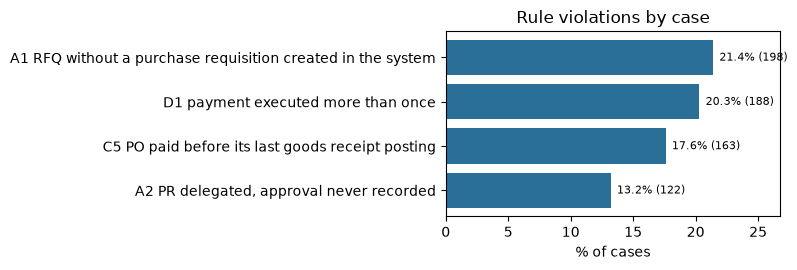

In [18]:
plot = dev[(dev.cases>0)&(dev.kind=='rule')].sort_values('cases')
fig, ax = plt.subplots(figsize=(8, 0.45*len(plot)+1))
ax.barh(plot.rule, plot.cases_pct, color='#2a6f97')
for y,(v,c) in enumerate(zip(plot.cases_pct, plot.cases)): ax.text(v+0.5, y, f'{v}% ({c})', va='center', fontsize=8)
ax.set_xlabel('% of cases'); ax.set_title('Rule violations by case'); ax.set_xlim(0, plot.cases_pct.max()*1.25)
fig.tight_layout(); fig.savefig(FIG/'03_rule_violations.png', dpi=150)

## 6. ตารางผลรายเคส (ใช้ในเว็บ)

In [19]:
case_rules = pd.DataFrame(index=sorted(nv.index))
for k, cs in viol.items():
    case_rules[k.split()[0]] = case_rules.index.isin(cs)
case_rules['rules_broken'] = nv.reindex(case_rules.index).values
case_rules['alignment_fitness'] = fit.reindex(case_rules.index).round(4).values
case_rules.index.name = 'case'
case_rules.to_csv(Path.cwd().parent/'data'/'case_rules.csv')
R['case_rules_rows'] = len(case_rules)
case_rules.head()

,A1,A2,A3,B1,B2,B3,C1,C2,C3,C4,C5,D1,rules_broken,alignment_fitness
case,,,,,,,,,,,,,,
purchase_requisition:0:pr_trigger_0,False,False,False,False,False,False,False,False,False,False,False,False,0,1.0000
purchase_requisition:100:pr_trigger_100,False,False,False,False,False,False,False,False,False,False,True,False,1,0.9677
purchase_requisition:101:pr_trigger_101,False,False,False,False,False,False,False,False,False,False,False,False,0,1.0000
purchase_requisition:102:pr_trigger_102,False,False,False,False,False,False,False,False,False,False,False,False,0,1.0000
purchase_requisition:103:pr_trigger_103,False,False,False,False,False,False,False,False,False,False,False,False,0,1.0000


## 6. บันทึกตัวเลข

In [20]:
out = Path.cwd().parent/'results'/'03_conformance.json'
out.write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str)); print('saved', len(R), 'keys')

saved 35 keys
